# scGPT Embedding Inspection and UMAP Visualization

Author: Yuxuan Xu

Description:
This notebook inspects and visualizes cell embeddings generated by a
(scGPT) model. It focuses on understanding the structure of the learned
representation and evaluating its biological relevance.

Main steps:
- Check embedding dimensionality and basic statistics
- Inspect raw embedding values
- Load or generate UMAP representation
- Visualize embeddings using metadata annotations
- Assess biological structure and batch mixing

Goals:
- Evaluate whether scGPT embeddings preserve cell type structure
- Examine potential batch effects in the embedding space
- Compare representation quality with other methods (e.g. scimilarity, scVI)

Inputs:
- AnnData object with:
    - scGPT embeddings (`adata.obsm["X_scGPT"]`)
    - Optional UMAP coordinates
    - Metadata in `adata.obs`

Outputs:
- UMAP visualization plots
- Qualitative assessment of embedding quality

Notes:
- UMAP provides a 2D projection for visualization only
- Embedding quality should be evaluated together with quantitative metrics

In [2]:
import scanpy as sc
import anndata as ad

/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
adata = sc.read_h5ad("retina_scgpt_cell_emb_finetuned_umap.h5ad")

In [4]:
# Check the dimensionality of the high-dimensional embedding
# Expected output: (number of cells, 512) or (number of cells, 128)
print("scimilarity embedding shape:", adata.obsm['X_scGPT'].shape)


scimilarity Embedding shape: (20587, 512)


In [5]:
# Extract the high-dimensional embedding matrix
emb_matrix = adata.obsm['X_scGPT']

# Print the first 5 cells and their first 5 dimensions
print(emb_matrix[:5, :5])

[[ 0.54604244  0.5373302  -1.365495   -0.46256194  0.9590405 ]
 [ 0.55282557  0.52987534 -1.3901054  -0.46256563  0.9755223 ]
 [ 0.52559894  0.5249299  -1.3594749  -0.4707336   0.9906364 ]
 [ 0.54338694  0.53169113 -1.3716183  -0.47496754  0.97766584]
 [ 0.5362545   0.5282261  -1.3680679  -0.46755162  0.97427636]]


In [6]:
print(adata.obsm.keys())

KeysView(AxisArrays with keys: X_scGPT, X_scGPT_finetuned, X_scVI, X_umap, X_umap_scgpt_ft)


In [7]:
print(adata.obs.columns.tolist())

['reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sampleid', 'cell_type', 'assay', 'disease', 'sex', 'tissue

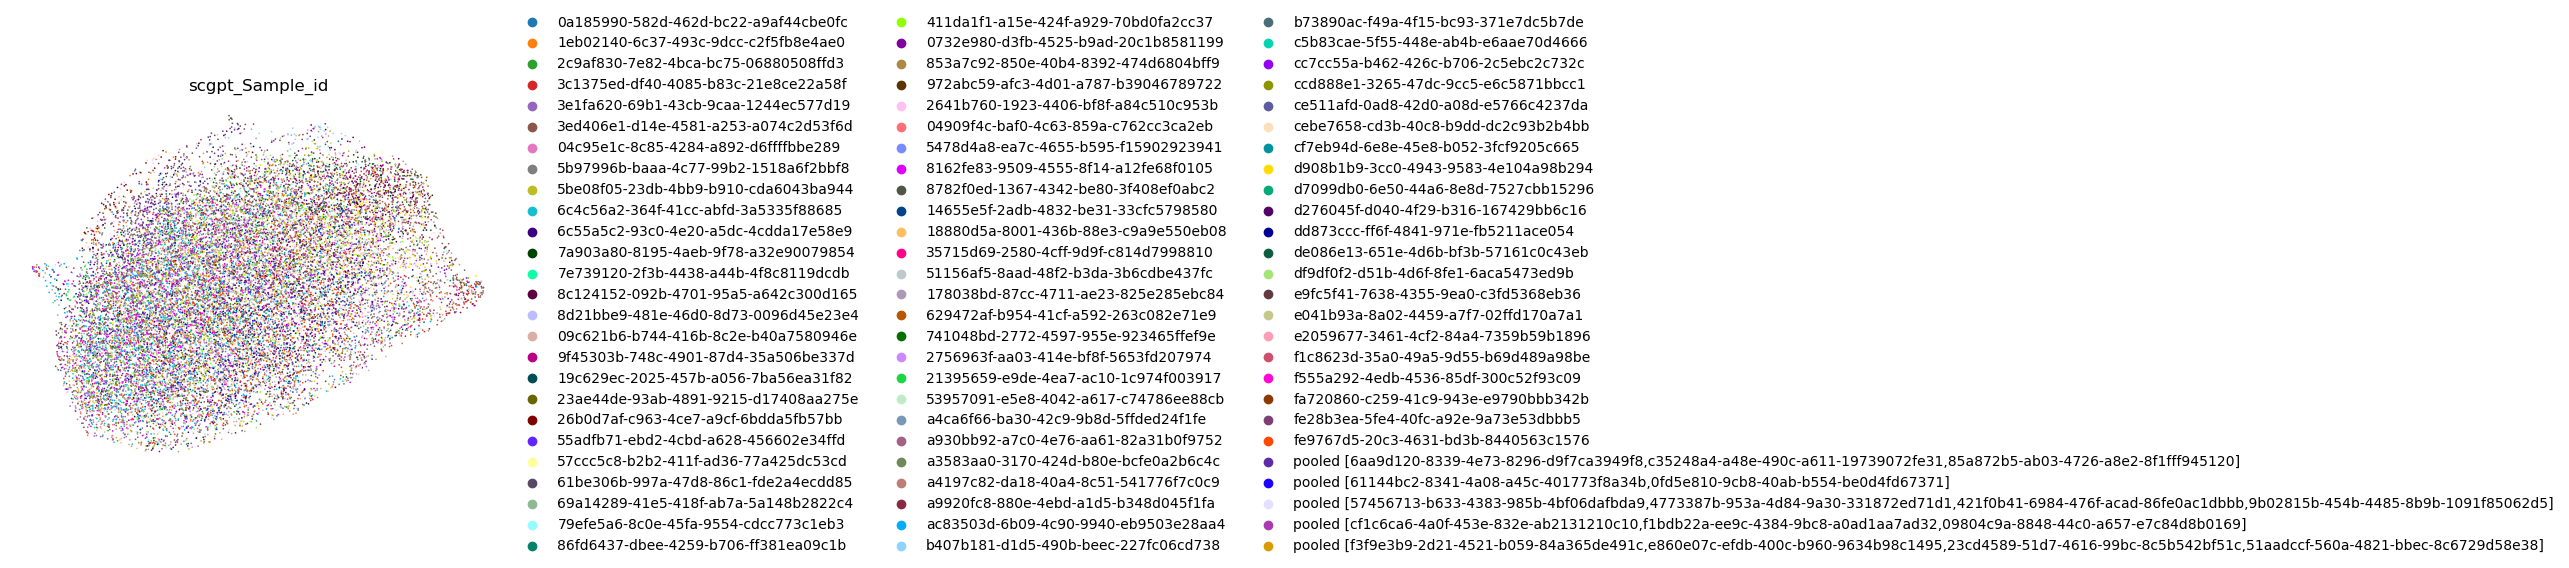

In [8]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap_scgpt_ft", 
    color=["sample_id"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["scgpt_Sample_id"],
    save = "_scimilarity_results.pdf"
)

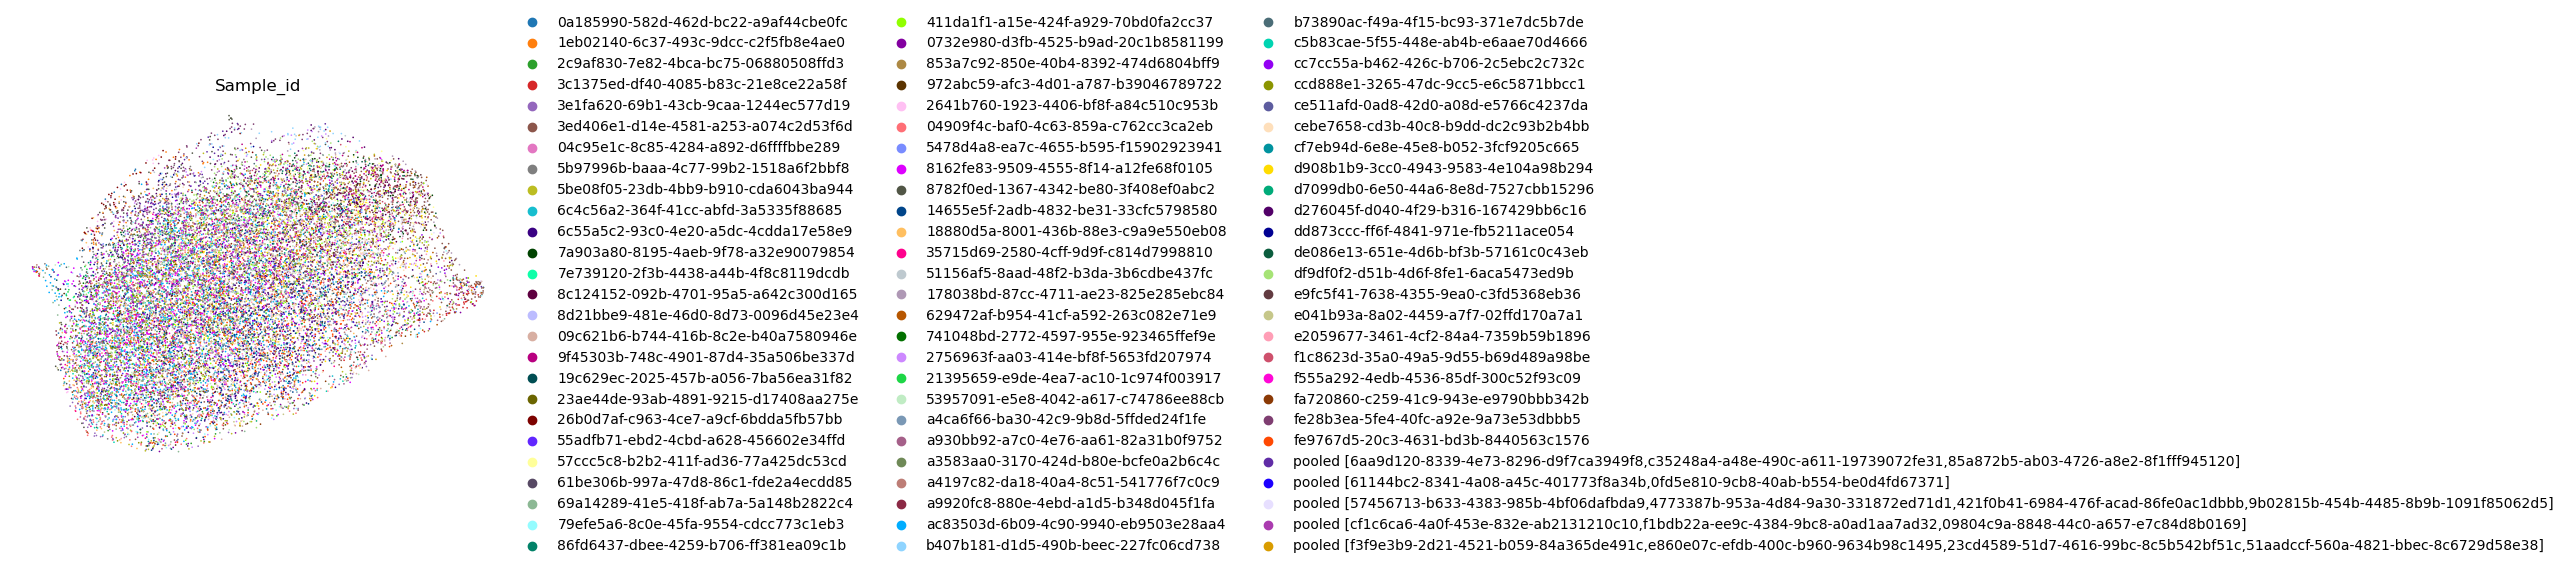

In [9]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap", 
    color=["sample_id"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["Sample_id"],
    save = "_scgpt_results.pdf"
)

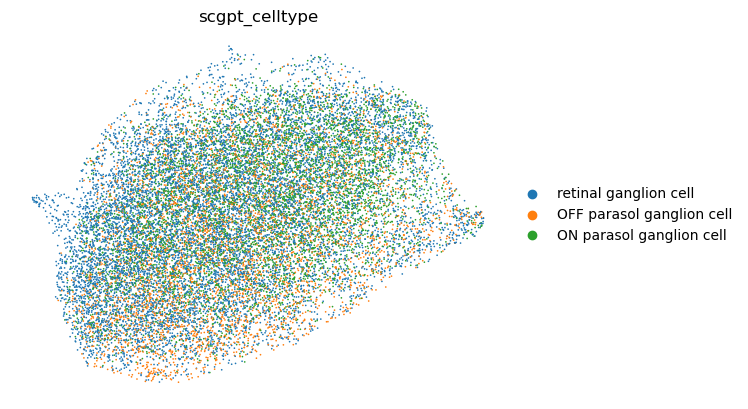

In [10]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap", 
    color=["cell_type"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["scgpt_celltype"],
    save = "_scgpt_results1.pdf"
)

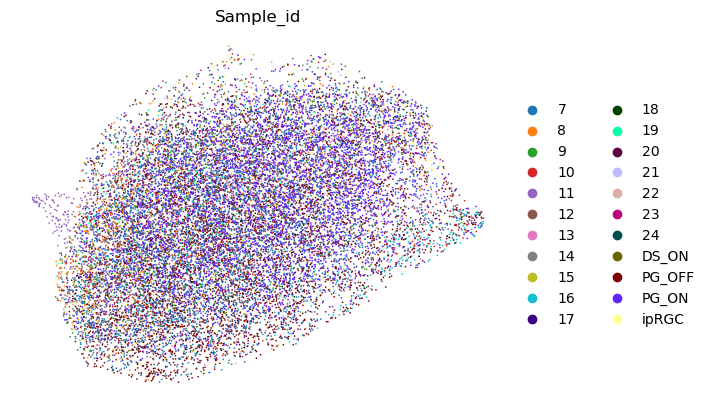

In [11]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap_scgpt_ft", 
    color=["RGC_celltype_number"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["Sample_id"],
    #save = "_scimilarity_results.pdf"
)

In [ ]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap", 
    color=["sample_id"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["Sample_id"],
    #save = "_scimilarity_results.pdf"
)